# Harbor Tasks Analysis

Analysis of task complexity distribution and diversity across the `harbor_tasks` dataset.

In [2]:
import json
import re
import os
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

TASKS_DIR = Path('harbor_tasks')

## 1. Load Task Data

In [3]:
tasks = []
for task_dir in sorted(TASKS_DIR.iterdir()):
    if not task_dir.is_dir() or not task_dir.name.startswith('task_'):
        continue
    
    task_json = task_dir / 'environment' / 'task.json'
    solve_sh = task_dir / 'solution' / 'solve.sh'
    test_file = task_dir / 'tests' / 'test_final_state.py'
    task_toml = task_dir / 'task.toml'
    instruction_md = task_dir / 'instruction.md'
    
    with open(task_json) as f:
        tj = json.load(f)
    
    desc = tj['description']
    truth = tj['truth']
    
    # Read solve.sh
    solve_code = solve_sh.read_text() if solve_sh.exists() else ''
    solve_lines = [l for l in solve_code.strip().splitlines() if l.strip() and not l.strip().startswith('#')]
    
    # Read test file
    test_code = test_file.read_text() if test_file.exists() else ''
    num_asserts = len(re.findall(r'\bassert\b', test_code))
    num_test_funcs = len(re.findall(r'def test_', test_code))
    test_lines_count = len(test_code.splitlines())
    
    # Count numbered steps in description
    numbered_steps = re.findall(r'^\s*\d+\.', desc, re.MULTILINE)
    
    # Extract tools/commands from solve.sh (first word of non-comment lines)
    commands_used = set()
    for line in solve_code.splitlines():
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('set '):
            continue
        # Handle heredocs, variable assignments, etc.
        if '=' in line and not line.startswith('export'):
            continue
        cmd = line.split()[0] if line.split() else ''
        if cmd and not cmd.startswith(('EOF', '{', '}', '>', '<', '|', 'then', 'else', 'fi', 'do', 'done', 'local', 'if', 'for', 'while')):
            commands_used.add(cmd)
    
    # Categorize task by keywords
    desc_lower = desc.lower()
    categories = []
    if any(w in desc_lower for w in ['log', 'access log', 'analyze', 'log file']):
        categories.append('Log Analysis')
    if any(w in desc_lower for w in ['archive', 'tar', 'backup', 'compress']):
        categories.append('Archive/Backup')
    if any(w in desc_lower for w in ['git', 'repository', 'submodule', 'commit']):
        categories.append('Git Operations')
    if any(w in desc_lower for w in ['api', 'endpoint', 'curl', 'fetch', 'scrape', 'headless']):
        categories.append('API/Web')
    if any(w in desc_lower for w in ['script', 'monitor', 'disk', 'pipeline']):
        categories.append('Scripting/Automation')
    if any(w in desc_lower for w in ['csv', 'json', 'data', 'transform', 'filter', 'parse']):
        categories.append('Data Processing')
    if any(w in desc_lower for w in ['encrypt', 'gpg', 'sign', 'security', 'vulnerability', 'penetration']):
        categories.append('Security')
    if any(w in desc_lower for w in ['kubernetes', 'k8s', 'manifest', 'deploy', 'build']):
        categories.append('DevOps/Infra')
    if not categories:
        categories.append('Other')
    
    tasks.append({
        'task_id': task_dir.name,
        'description': desc,
        'description_len': len(desc),
        'truth_len': len(truth),
        'num_steps': len(numbered_steps),
        'solve_lines': len(solve_lines),
        'num_asserts': num_asserts,
        'num_test_funcs': num_test_funcs,
        'test_lines': test_lines_count,
        'num_commands': len(commands_used),
        'commands': commands_used,
        'categories': categories,
        'primary_category': categories[0],
    })

df = pd.DataFrame(tasks)
print(f'Loaded {len(df)} tasks')
df[['task_id', 'description_len', 'num_steps', 'solve_lines', 'num_asserts', 'num_test_funcs', 'primary_category']].head(19)

Loaded 19 tasks


,task_id,description_len,num_steps,solve_lines,num_asserts,num_test_funcs,primary_category
0,task_000000_177169b6,1194,3,7,25,19,Log Analysis
1,task_000000_2268a271,1600,4,8,25,25,Log Analysis
2,task_000000_31c5d8d7,1202,3,25,26,19,Log Analysis
3,task_000000_3294be7a,1910,5,0,27,18,Log Analysis
4,task_000000_33870ccf,2298,0,50,31,25,Log Analysis
5,task_000000_34a19345,1199,4,13,20,17,Log Analysis
6,task_000000_3f80b471,1092,3,8,20,18,Log Analysis
7,task_000000_5176e648,1704,3,43,29,22,Scripting/Automation
8,task_000000_53faffc0,1685,5,64,30,16,Log Analysis
9,task_000000_659a19e1,1125,2,18,43,17,Log Analysis


## 2. Task Complexity Analysis

We define complexity using multiple proxy signals:
- **Description length** – longer specs tend to be more involved
- **Number of explicit steps** – enumerated sub-tasks in the description
- **Solution length** – lines of code in the reference `solve.sh`
- **Test surface** – number of assertions and test functions
- **Distinct commands** – unique CLI tools required in the solution

In [4]:
# Composite complexity score (z-score average of key metrics)
complexity_cols = ['description_len', 'num_steps', 'solve_lines', 'num_asserts', 'num_test_funcs', 'num_commands']

for col in complexity_cols:
    mean, std = df[col].mean(), df[col].std()
    df[f'{col}_z'] = (df[col] - mean) / std if std > 0 else 0

z_cols = [f'{c}_z' for c in complexity_cols]
df['complexity_score'] = df[z_cols].mean(axis=1)

# Bin into Low / Medium / High
df['complexity_bin'] = pd.cut(df['complexity_score'],
                              bins=[-np.inf, -0.3, 0.3, np.inf],
                              labels=['Low', 'Medium', 'High'])

print('Complexity distribution:')
print(df['complexity_bin'].value_counts().sort_index())
print(f'\nComplexity score range: [{df["complexity_score"].min():.2f}, {df["complexity_score"].max():.2f}]')

Complexity distribution:
complexity_bin
Low       8
Medium    6
High      5
Name: count, dtype: int64

Complexity score range: [-0.63, 1.19]


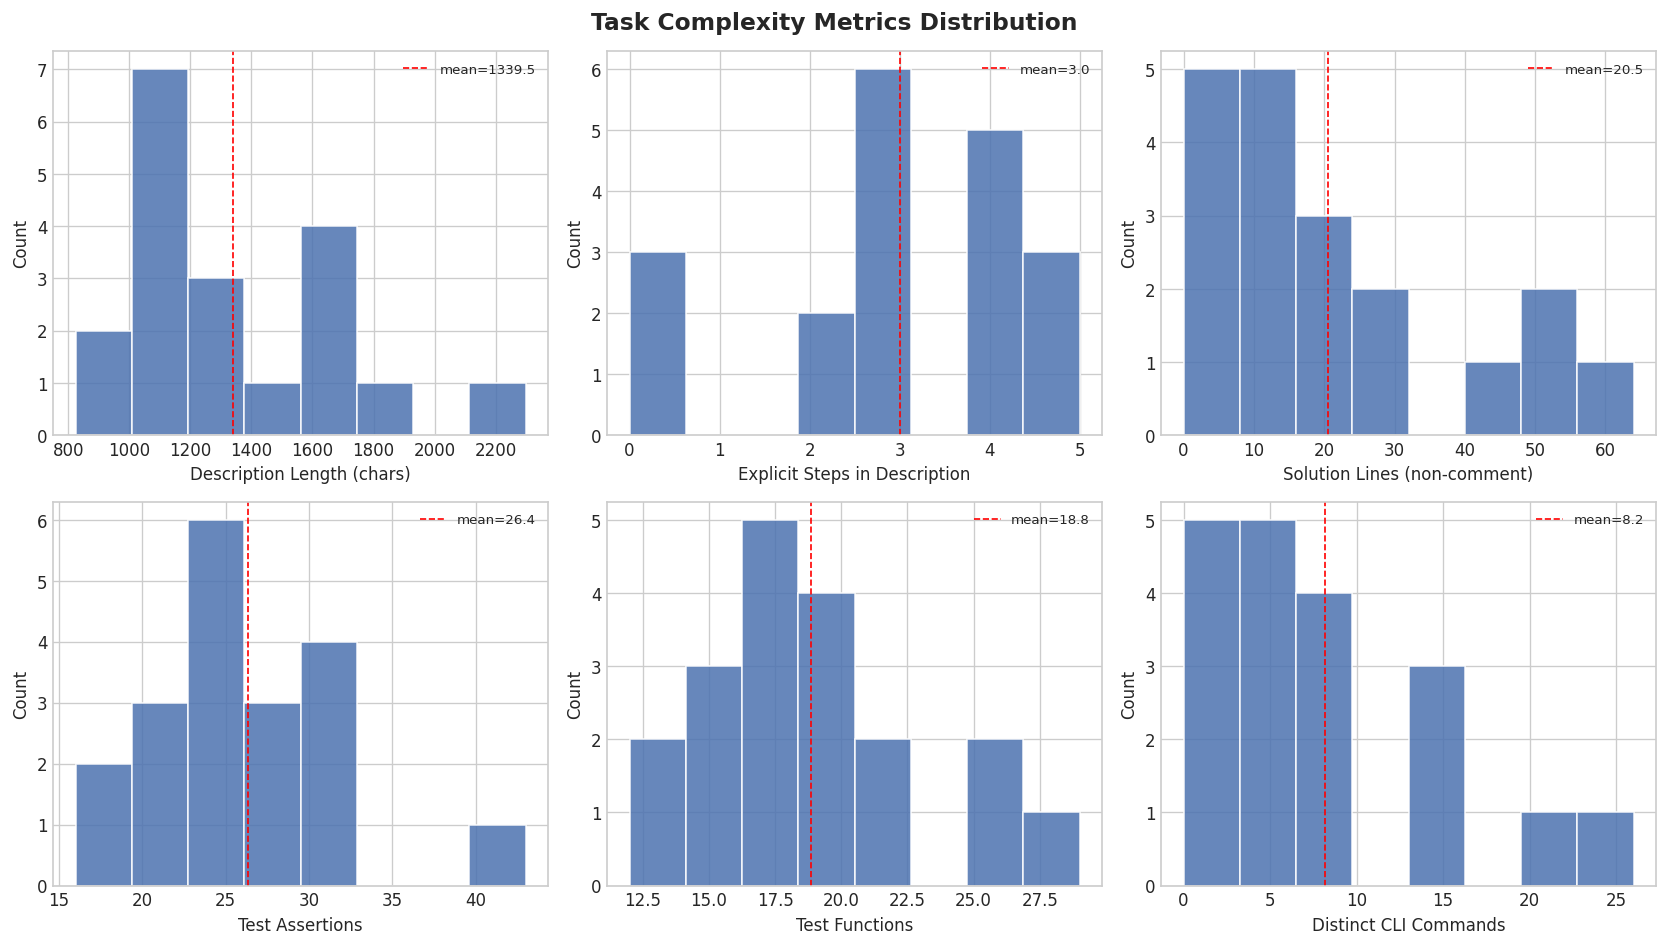

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Task Complexity Metrics Distribution', fontsize=14, fontweight='bold')

metric_labels = {
    'description_len': 'Description Length (chars)',
    'num_steps': 'Explicit Steps in Description',
    'solve_lines': 'Solution Lines (non-comment)',
    'num_asserts': 'Test Assertions',
    'num_test_funcs': 'Test Functions',
    'num_commands': 'Distinct CLI Commands',
}

for ax, col in zip(axes.flat, complexity_cols):
    ax.hist(df[col], bins=8, edgecolor='white', color='#4C72B0', alpha=0.85)
    ax.set_xlabel(metric_labels[col])
    ax.set_ylabel('Count')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label=f'mean={df[col].mean():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

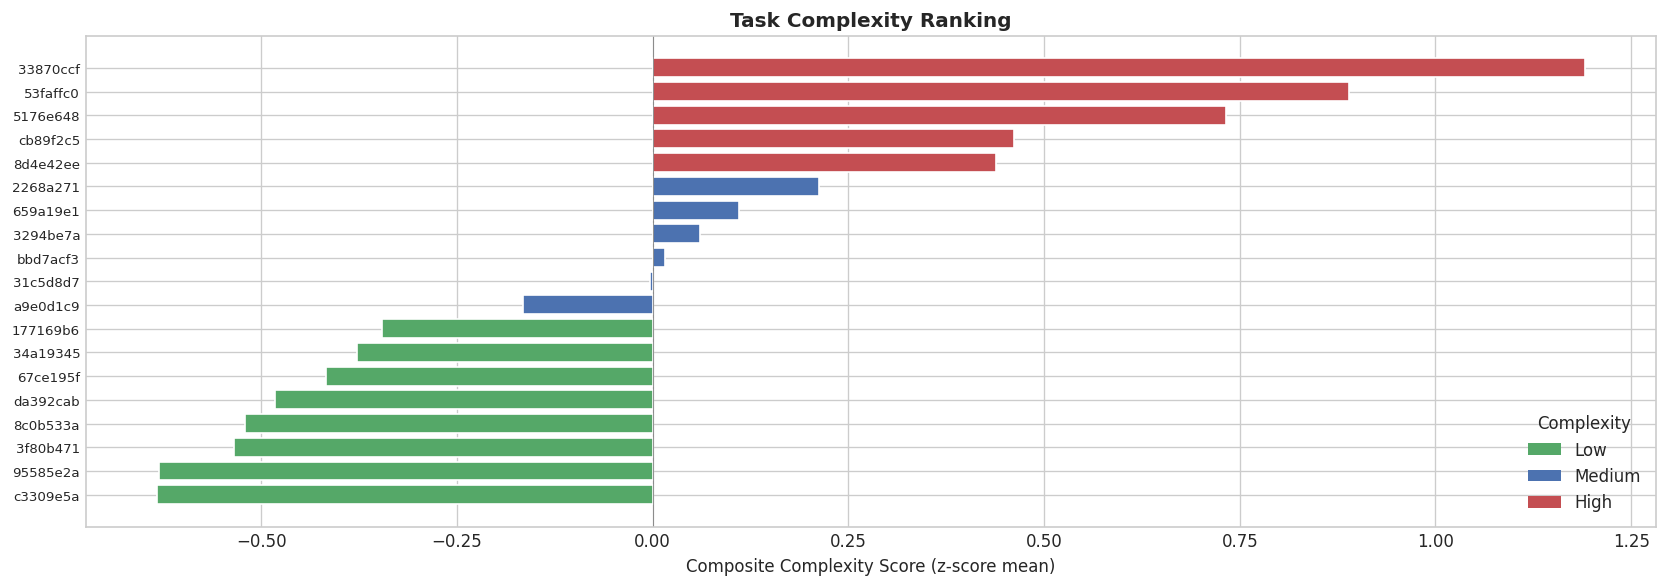

In [6]:
# Composite complexity score per task
fig, ax = plt.subplots(figsize=(14, 5))
sorted_df = df.sort_values('complexity_score')
colors = {'Low': '#55a868', 'Medium': '#4c72b0', 'High': '#c44e52'}
bar_colors = [colors[b] for b in sorted_df['complexity_bin']]

short_ids = [tid.replace('task_000000_', '') for tid in sorted_df['task_id']]
ax.barh(range(len(sorted_df)), sorted_df['complexity_score'], color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(sorted_df)))
ax.set_yticklabels(short_ids, fontsize=8)
ax.set_xlabel('Composite Complexity Score (z-score mean)')
ax.set_title('Task Complexity Ranking', fontweight='bold')
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=k) for k in ['Low', 'Medium', 'High']]
ax.legend(handles=legend_elements, title='Complexity', loc='lower right')

plt.tight_layout()
plt.show()

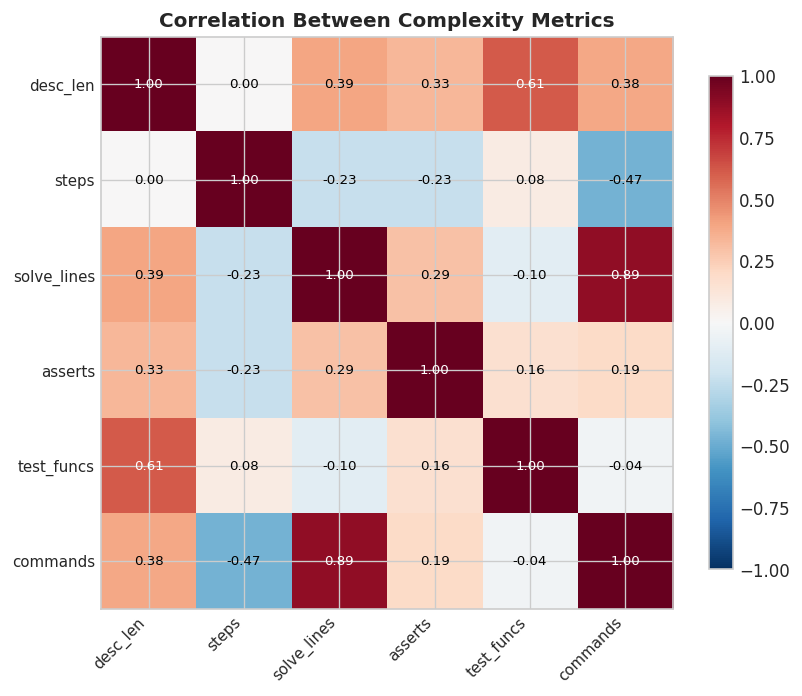

In [7]:
# Correlation heatmap of complexity metrics
fig, ax = plt.subplots(figsize=(7, 6))
corr = df[complexity_cols].corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(complexity_cols)))
ax.set_yticks(range(len(complexity_cols)))
short_labels = ['desc_len', 'steps', 'solve_lines', 'asserts', 'test_funcs', 'commands']
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

for i in range(len(complexity_cols)):
    for j in range(len(complexity_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation Between Complexity Metrics', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Task Diversity Analysis

We examine diversity along two axes:
1. **Thematic categories** – what domain does the task belong to?
2. **Tooling diversity** – which CLI commands/tools are exercised?

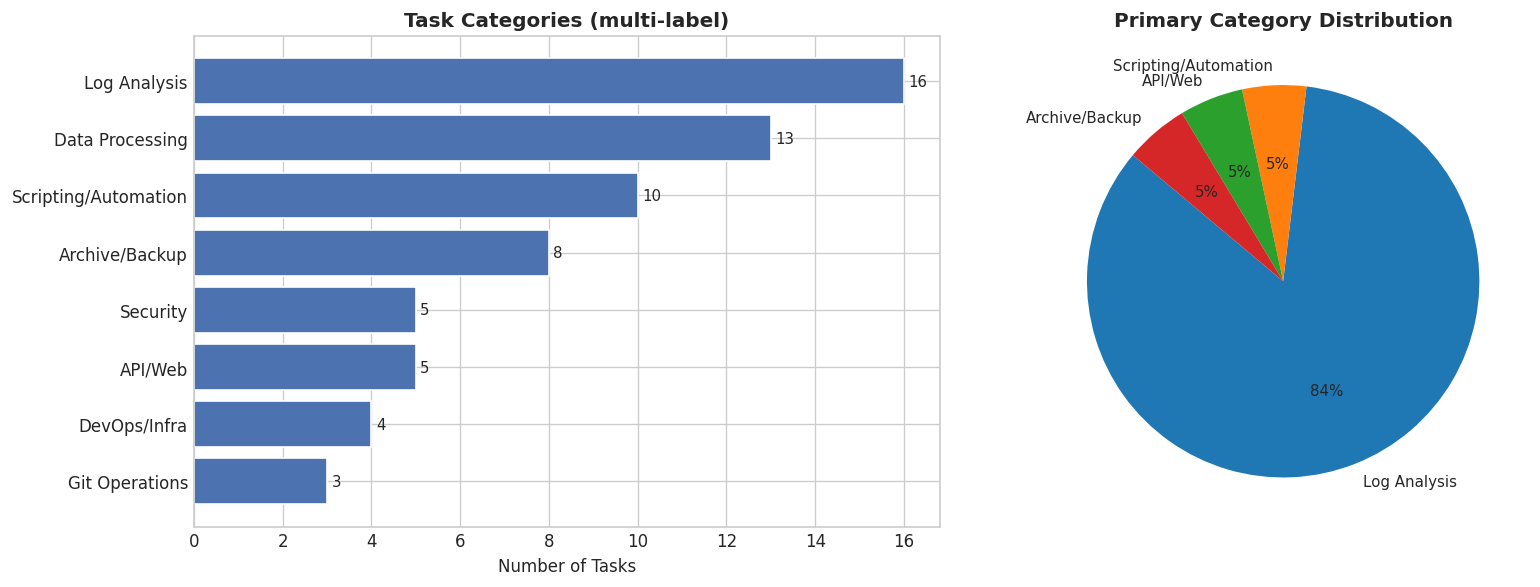


Unique categories: 8
Avg categories per task: 3.4


In [8]:
# Explode categories (tasks can have multiple)
all_cats = [cat for cats in df['categories'] for cat in cats]
cat_counts = Counter(all_cats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of categories
sorted_cats = sorted(cat_counts.items(), key=lambda x: -x[1])
labels, values = zip(*sorted_cats)
axes[0].barh(labels, values, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Number of Tasks')
axes[0].set_title('Task Categories (multi-label)', fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=9)

# Pie chart of primary category
primary_counts = df['primary_category'].value_counts()
axes[1].pie(primary_counts, labels=primary_counts.index, autopct='%1.0f%%',
            startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Primary Category Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nUnique categories: {len(cat_counts)}')
print(f'Avg categories per task: {len(all_cats)/len(df):.1f}')

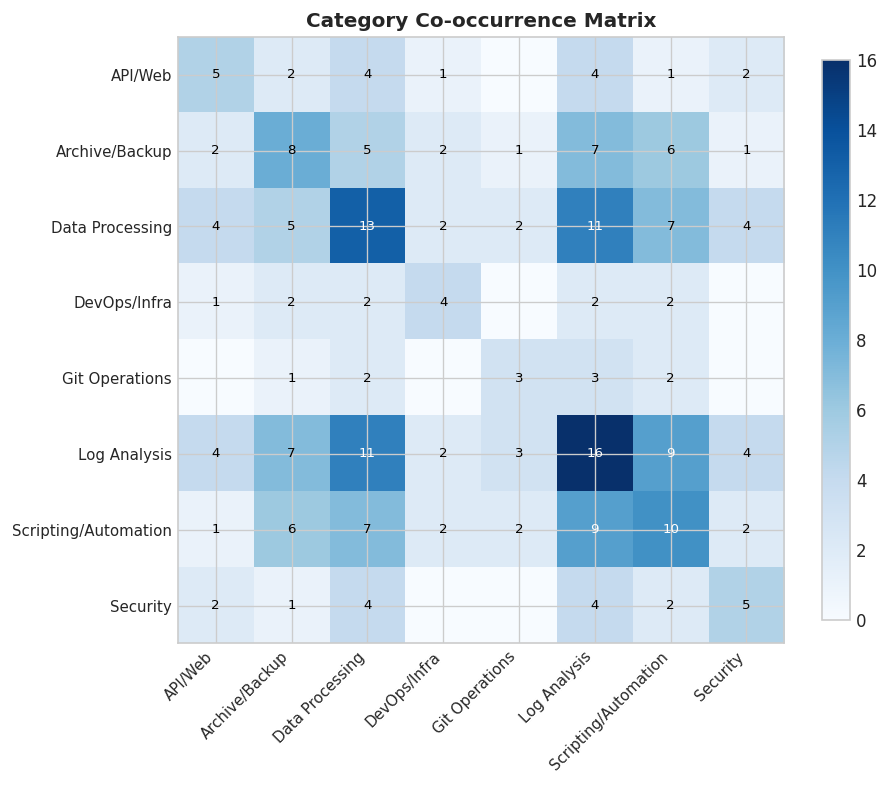

In [9]:
# Category co-occurrence matrix
all_cat_names = sorted(cat_counts.keys())
co_matrix = pd.DataFrame(0, index=all_cat_names, columns=all_cat_names)

for cats in df['categories']:
    for c1 in cats:
        for c2 in cats:
            co_matrix.loc[c1, c2] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(co_matrix.values, cmap='Blues')
ax.set_xticks(range(len(all_cat_names)))
ax.set_yticks(range(len(all_cat_names)))
ax.set_xticklabels(all_cat_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_cat_names, fontsize=9)

for i in range(len(all_cat_names)):
    for j in range(len(all_cat_names)):
        val = co_matrix.iloc[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8,
                    color='white' if val > co_matrix.values.max() * 0.5 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Category Co-occurrence Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

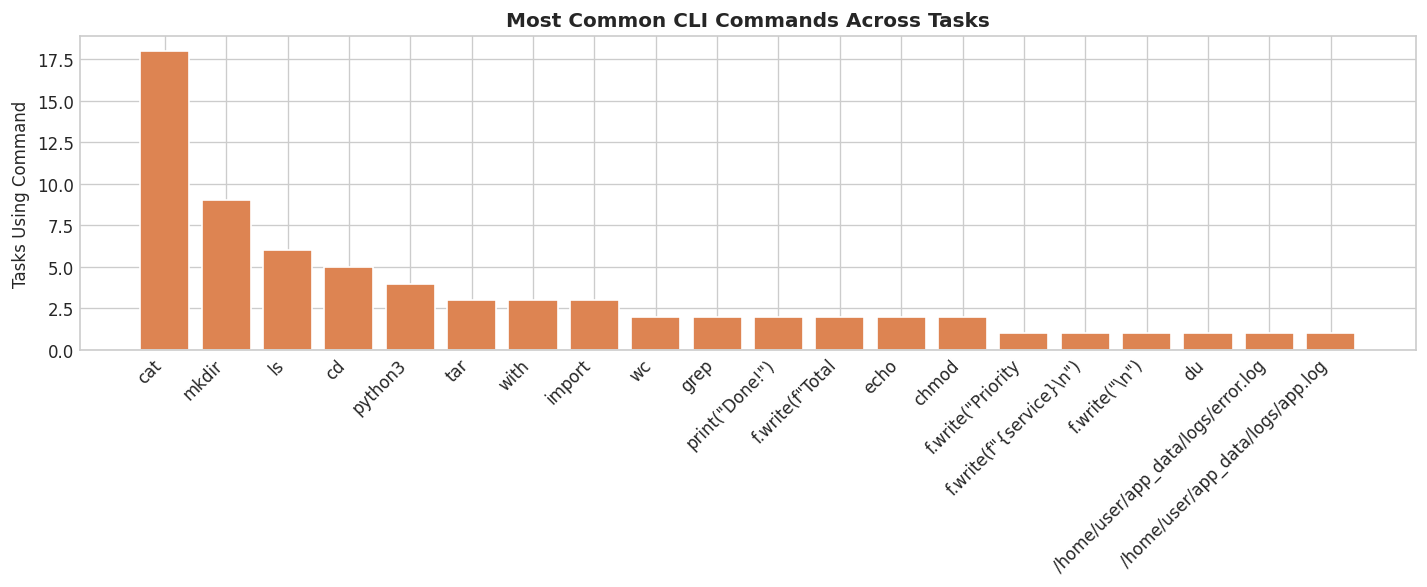

Total unique commands across all tasks: 106


In [10]:
# CLI tool/command diversity
all_commands = [cmd for cmds in df['commands'] for cmd in cmds]
cmd_counts = Counter(all_commands)

# Top commands
top_cmds = cmd_counts.most_common(20)

fig, ax = plt.subplots(figsize=(12, 5))
labels, values = zip(*top_cmds)
ax.bar(labels, values, color='#dd8452', edgecolor='white')
ax.set_ylabel('Tasks Using Command')
ax.set_title('Most Common CLI Commands Across Tasks', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total unique commands across all tasks: {len(cmd_counts)}')

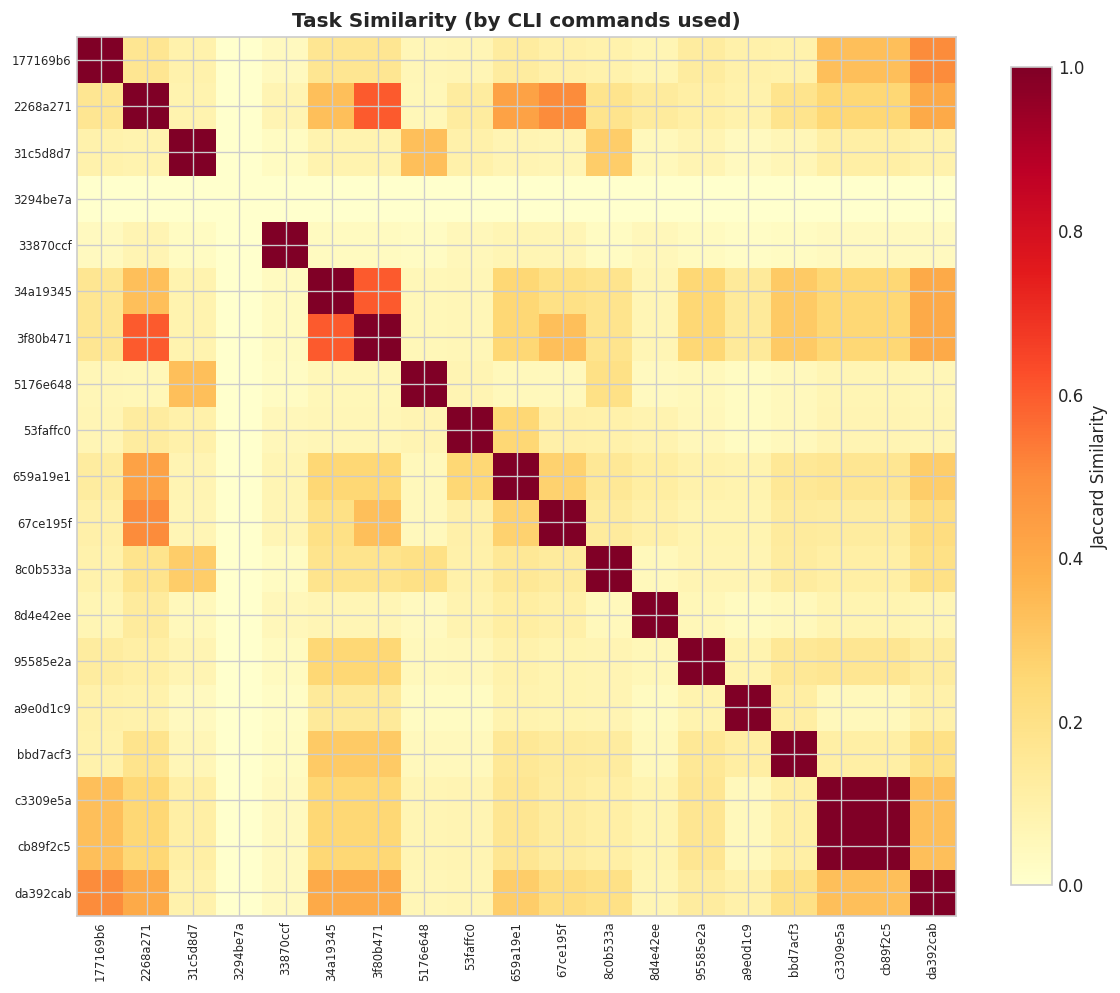

Mean pairwise Jaccard similarity: 0.131
Max pairwise Jaccard similarity: 1.000


In [11]:
# Jaccard similarity between tasks (based on command sets)
n = len(df)
jaccard = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        s1, s2 = df.iloc[i]['commands'], df.iloc[j]['commands']
        if len(s1 | s2) == 0:
            jaccard[i, j] = 0
        else:
            jaccard[i, j] = len(s1 & s2) / len(s1 | s2)

short_ids = [tid.replace('task_000000_', '') for tid in df['task_id']]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(jaccard, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_ids, rotation=90, fontsize=7)
ax.set_yticklabels(short_ids, fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8, label='Jaccard Similarity')
ax.set_title('Task Similarity (by CLI commands used)', fontweight='bold')
plt.tight_layout()
plt.show()

# Off-diagonal mean
mask = ~np.eye(n, dtype=bool)
print(f'Mean pairwise Jaccard similarity: {jaccard[mask].mean():.3f}')
print(f'Max pairwise Jaccard similarity: {jaccard[mask].max():.3f}')

## 4. Summary Statistics

In [12]:
summary = df[complexity_cols + ['complexity_score']].describe().round(1)
summary.columns = ['Desc Length', 'Steps', 'Solution Lines', 'Assertions', 'Test Funcs', 'Commands', 'Complexity Score']
summary

,Desc Length,Steps,Solution Lines,Assertions,Test Funcs,Commands,Complexity Score
count,19.0,19.0,19.0,19.0,19.0,19.0,19.0
mean,1339.5,3.0,20.5,26.4,18.8,8.2,0.0
std,374.2,1.6,18.2,6.0,4.2,6.9,0.5
min,824.0,0.0,0.0,16.0,12.0,0.0,-0.6
25%,1107.5,2.5,7.5,23.0,16.5,3.5,-0.5
50%,1194.0,3.0,14.0,26.0,18.0,6.0,-0.0
75%,1607.5,4.0,26.5,29.5,20.5,11.0,0.3
max,2298.0,5.0,64.0,43.0,29.0,26.0,1.2


In [13]:
# Per-task summary table
display_df = df[['task_id', 'primary_category', 'num_steps', 'solve_lines', 'num_asserts', 'num_commands', 'complexity_bin']].copy()
display_df.columns = ['Task ID', 'Category', 'Steps', 'Solution Lines', 'Assertions', 'Commands', 'Complexity']
display_df['Task ID'] = display_df['Task ID'].str.replace('task_000000_', '')
display_df = display_df.sort_values('Complexity', ascending=False)
display_df

,Task ID,Category,Steps,Solution Lines,Assertions,Commands,Complexity
4,33870ccf,Log Analysis,0,50,31,26,High
17,cb89f2c5,Archive/Backup,4,7,31,1,High
7,5176e648,Scripting/Automation,3,43,29,15,High
8,53faffc0,Log Analysis,5,64,30,14,High
12,8d4e42ee,Log Analysis,4,28,26,13,High
9,659a19e1,Log Analysis,2,18,43,6,Medium
2,31c5d8d7,Log Analysis,3,25,26,9,Medium
3,3294be7a,Log Analysis,5,0,27,0,Medium
1,2268a271,Log Analysis,4,8,25,4,Medium
15,bbd7acf3,Log Analysis,4,22,32,9,Medium


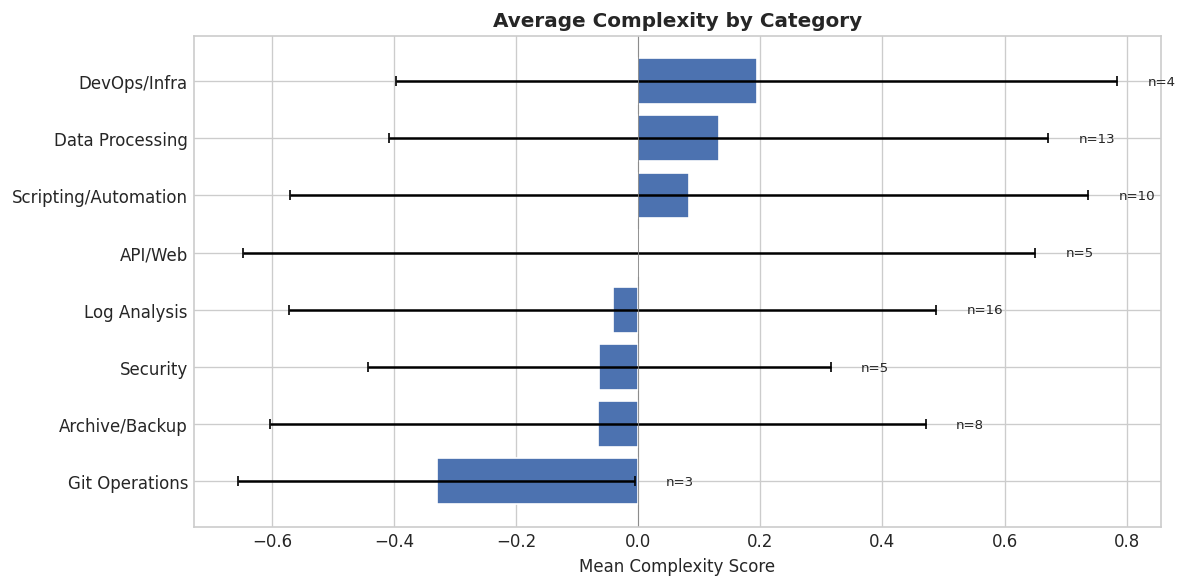

In [14]:
# Complexity vs. category
fig, ax = plt.subplots(figsize=(10, 5))
cat_complexity = df.explode('categories').groupby('categories')['complexity_score'].agg(['mean', 'std', 'count'])
cat_complexity = cat_complexity.sort_values('mean')

ax.barh(cat_complexity.index, cat_complexity['mean'], xerr=cat_complexity['std'],
        color='#4c72b0', edgecolor='white', capsize=3)
ax.set_xlabel('Mean Complexity Score')
ax.set_title('Average Complexity by Category', fontweight='bold')
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)

# Annotate with count
for i, (idx, row) in enumerate(cat_complexity.iterrows()):
    ax.text(row['mean'] + row['std'] + 0.05, i, f'n={int(row["count"])}', va='center', fontsize=8)

plt.tight_layout()
plt.show()